In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Technical Content/data/tanzania.csv')
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16


In [3]:
df["Country"] = "Tanzania"
df["date"] = pd.to_datetime(
df["YEAR"]*1000 + df["DOY"],
format="%Y%j"
)
df["Month"] = df["date"].dt.month

In [4]:
print("Missing values:")
print(df.isna().sum().sum())
print("Duplicates:")
print(df.duplicated().sum())

Missing values:
0
Duplicates:
0


In [6]:
df.to_csv("/content/drive/MyDrive/tanzania_clean.csv", index=False)

In [7]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046


Tanzania has a warm and relatively stable tropical climate, with an average daily temperature of 26.80°C. The low standard deviation shows limited temperature fluctuations throughout the year, indicating consistent climatic conditions. Compared to drier countries like Sudan, Tanzania experiences less extreme temperature variation and lower heat stress risk.

In [8]:
(df["T2M_MAX"] > 35).sum()

np.int64(0)

Tanzania recorded zero days where maximum temperature exceeded 35°C during the study period. This suggests that extreme heat events are uncommon, and climate vulnerability is more strongly associated with rainfall patterns and agricultural dependence rather than severe heat stress.

In [9]:
from scipy.stats import zscore
import numpy as np

cols = ['T2M','PRECTOTCORR']
z = np.abs(zscore(df[cols]))
(z > 3).sum()

np.int64(82)

A total of 82 outlier observations were detected using Z-score analysis. These outliers likely represent unusual rainfall events or temporary climate extremes rather than data errors. Since such events are important indicators of climate variability and vulnerability, they were retained for analysis.

In [10]:
import matplotlib.pyplot as plt

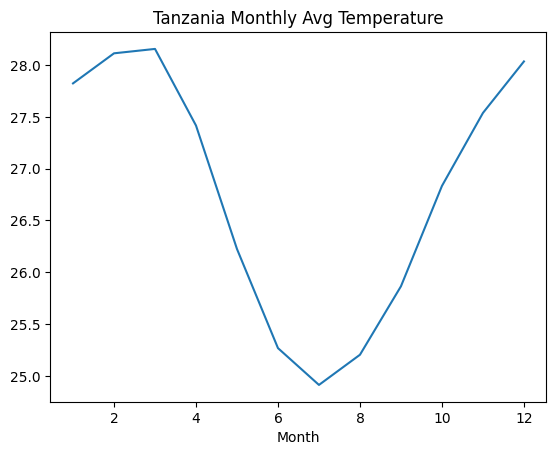

In [18]:
df.groupby('Month')['T2M'].mean().plot()
plt.title("Tanzania Monthly Avg Temperature")
plt.show()

The monthly average temperature line chart shows a relatively smooth seasonal pattern with minor fluctuations throughout the year. Temperatures are generally highest at the beginning of the year and lowest around the middle of the year. This reflects Tanzania’s tropical climate with moderate seasonal variation rather than extreme heat cycles.

February appears to be the warmest month, representing the peak of the hot season before the long rainy period begins. This period is important for agriculture because rising temperatures increase evaporation and water demand.

July appears to be the coolest month, reflecting the cooler dry season in East Africa. Reduced temperatures during this period are influenced by seasonal wind patterns and lower atmospheric moisture.

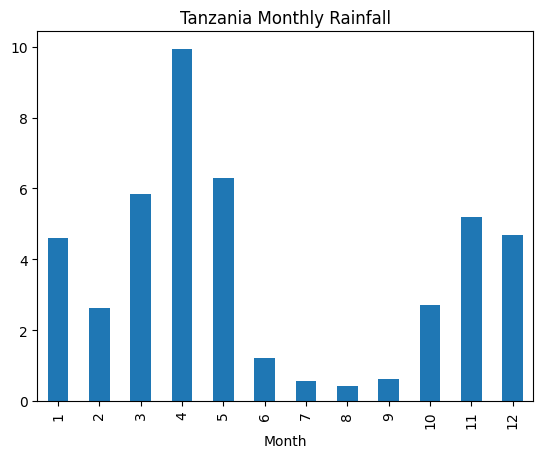

In [19]:
df.groupby('Month')['PRECTOTCORR'].mean().plot(kind='bar')
plt.title("Tanzania Monthly Rainfall")
plt.show()

Rainfall is strongly seasonal, with most precipitation concentrated during a few months of the year. This indicates high dependence on predictable rainy seasons for agriculture, hydropower, and water supply.

April is likely the peak rainy month, corresponding to Tanzania’s long rainy season. Heavy rainfall during this month supports crop production but also increases flood risk if rainfall intensity becomes extreme.

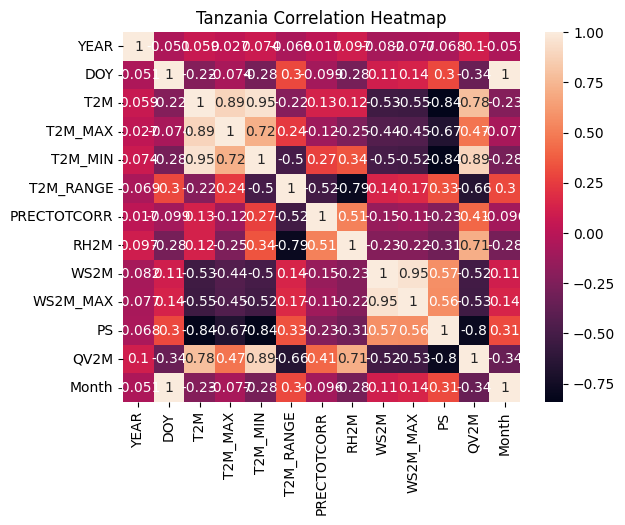

In [17]:
import seaborn as sns
numeric_df = df.select_dtypes(include=["number"])
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Tanzania Correlation Heatmap")
plt.show()

The heatmap shows strong positive relationships between mean temperature, maximum temperature, and minimum temperature, which is expected in climate datasets. Relative humidity tends to increase during wetter periods, while precipitation is closely associated with higher atmospheric moisture.

Mean temperature strongly increases with maximum temperature, showing that hotter daytime conditions significantly raise daily average temperatures.

Mean temperature also has a strong positive relationship with minimum temperature, indicating that nighttime temperatures contribute consistently to Tanzania’s warm climate profile.

Relative humidity and precipitation show a positive relationship because wetter months naturally have higher atmospheric moisture and stronger rainfall events.

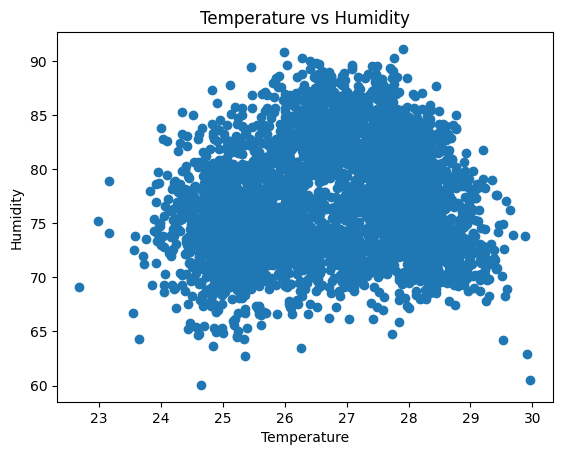

In [14]:
plt.scatter(df["T2M"], df["RH2M"])
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.title("Temperature vs Humidity")
plt.show()

The scatter plot suggests that higher humidity is often associated with moderate temperatures rather than the hottest periods. This reflects the tropical rainfall cycle where moisture increases during rainy seasons and decreases during hotter dry periods.

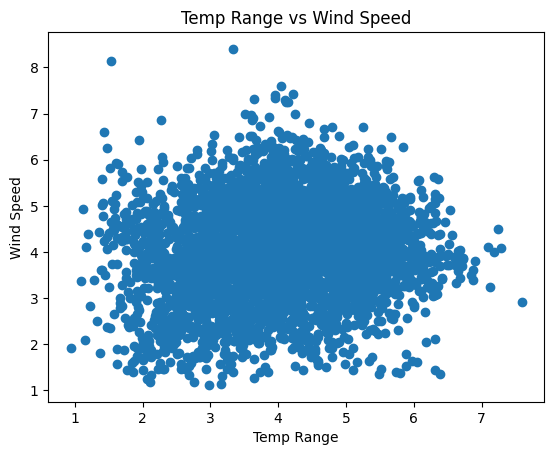

In [15]:
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.xlabel("Temp Range")
plt.ylabel("Wind Speed")
plt.title("Temp Range vs Wind Speed")
plt.show()

The relationship between daily temperature range and wind speed appears relatively weak, suggesting that wind speed does not strongly determine temperature variation. Seasonal atmospheric conditions may still influence both variables indirectly.

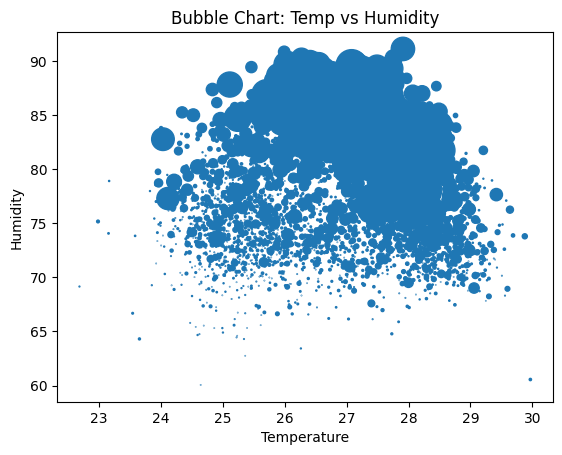

In [16]:
plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"]*10
)
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.title("Bubble Chart: Temp vs Humidity")
plt.show()

Larger precipitation events are concentrated where humidity is higher and temperatures are moderate. This confirms that rainfall in Tanzania is strongly linked to atmospheric moisture availability and seasonal wet periods.